In [12]:
import tensorflow as tf
import os

base_dir = "C:/Users/RICKY/Desktop/AI/Python/vehicle-type-recognition/Dataset"

In [13]:
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Display class names
class_names = train_ds.class_names
print("Class names:", class_names)


Found 336 files belonging to 4 classes.
Found 336 files belonging to 4 classes.
Class names: ['Bus', 'Car', 'Truck', 'motorcycle']


In [14]:
# Load ResNet50 base
mobile_net = tf.keras.applications.MobileNetV2(
    input_shape = (224,224,3),
    include_top = False,
    weights = 'imagenet'
)

#freeze the base
mobile_net.trainable = False

In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    mobile_net,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')  # Multiclass classification
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.3478 - loss: 1.7458 - val_accuracy: 0.6310 - val_loss: 0.9453
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5742 - loss: 1.0188 - val_accuracy: 0.7381 - val_loss: 0.7888
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.6179 - loss: 0.9025 - val_accuracy: 0.7321 - val_loss: 0.6878
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.6865 - loss: 0.7793 - val_accuracy: 0.8006 - val_loss: 0.5673
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7253 - loss: 0.6637 - val_accuracy: 0.8363 - val_loss: 0.4957
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7609 - loss: 0.6280 - val_accuracy: 0.8780 - val_loss: 0.4408
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8023 - loss: 0.5806 - val_accuracy: 0.8839 - val_loss: 0.4094
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8161 - loss: 0.4493 - val_accuracy: 0.9048 - val_loss:

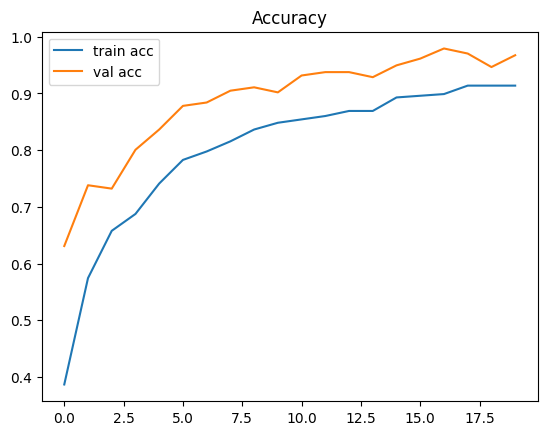

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label= 'train acc')
plt.plot(history.history['val_accuracy'], label= 'val acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [18]:
model.save("model.h5")